In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import os
from random import randrange
from scipy.optimize import curve_fit
from scipy.optimize import OptimizeWarning
from scipy.stats import chi2
import warnings
import sys
import colorcet as cc
import multiprocessing

sys.path.append(os.path.join(os.path.dirname(
    os.path.abspath(''))))
import common.plots as plots
import common.potential_data as potential_data
import common.fit as fit

warnings.simplefilter("ignore", OptimizeWarning)
warnings.simplefilter("ignore", RuntimeWarning)

In [40]:
def plot_potential_gevp_single_original(lattice_size, beta, smearing, space_size, time_size):
    show_plot = False
    coordinate = 'r/a'
    hue = 'params'
    decomposition_type = 'original'
    paths = [{'path': f'../../result/potential_gevp/fundamental/on-axis/su3/gluodynamics/{lattice_size}/{beta}/{decomposition_type}/{smearing}/potential_{decomposition_type}.csv',
              'parameters': {'params': f'{lattice_size}, {beta}, {decomposition_type}'}, 'constraints': {'time_size': (1, time_size // 2), 'space_size': (1, space_size // 2)}}]
    image_path = f'../../images/potential_gevp/su3/gluodynamics/potentials_single/{lattice_size}/{beta}/{smearing}'
    image_name = f'potential_{decomposition_type}'
    df = potential_data.get_potantial_df(paths, coluns_to_multiindex=['params'])
    df = df.rename({'potential': 'aV(r)', 'space_size': 'r/a', 'time_size': 'T'}, axis=1)
    df = df[df['aV(r)'] != 0]
    index = []
    if df.index.names[0] is not None:
        index = df.index.names
    # print(df.to_string())
    df = df.set_index(['r/a'], append=True).groupby(index + ['r/a']).apply(fit.potential_fit_T_range, fit.func_exponent, ['V', 'a', 'b'], max(time_size // 2 - 4, 6), include_groups=False).reset_index(level=['r/a']).reset_index(level=-1, drop=True)
    df = df.drop('T', axis = 1)
    df_fit = df.groupby(index).apply(fit.make_fit_range, fit.func_cornell, ['V0', 'alpha', 'sigma'], 'r/a', 'aV(r)', 'err', range_min_len=max(space_size // 2 - 4, 6), include_groups=False).reset_index(level=-1, drop=True)
    df_fit = df_fit.groupby(index).apply(fit.average_fit_p_value, ['V0', 'alpha', 'sigma'], 'r/a', include_groups=False).reset_index(level=-1, drop=True)
    index_fit = []
    if df.index.names[0] is not None:
        index_fit = df.index.names
    df_curves = df_fit.groupby(index_fit).apply(fit.make_fit_curve, fit.func_cornell, 'r/a', 'aV(r)', ['V0', 'alpha', 'sigma'], include_groups=False).reset_index(level=-1, drop=True)
    df = df.reset_index(level=index)
    df_curves = df_curves.reset_index(level=index)
    plots.plot_potential_single(df, coordinate, 'aV(r)', hue, 'r/a', 'aV(r)', 'original potential', image_path, image_name, show_plot, err='err', df_fits=df_curves)
    plt.close()

In [41]:
plot_potential_gevp_single_original('16^4', 'beta6.0', 'HYP0_alpha=1_1_0.5_APE_alpha=0.5', 16, 16)

ValueError: No objects to concatenate

In [17]:
plot_potential_gevp_single_original('24^4', 'beta6.0', 'HYP0_alpha=1_1_0.5_APE_alpha=0.5', 24, 24)

In [18]:
plot_potential_gevp_single_original('32^4', 'beta6.0', 'HYP0_alpha=1_1_0.5_APE_alpha=0.5', 32, 32)

In [19]:
plot_potential_gevp_single_original('28^4', 'beta6.1', 'HYP0_alpha=1_1_0.5_APE_alpha=0.5', 28, 28)

In [20]:
plot_potential_gevp_single_original('32^4', 'beta6.2', 'HYP0_alpha=1_1_0.5_APE_alpha=0.5', 32, 32)

In [21]:
plot_potential_gevp_single_original('36^4', 'beta6.3', 'HYP0_alpha=1_1_0.5_APE_alpha=0.5', 36, 36)

In [22]:
plot_potential_gevp_single_original('40^4', 'beta6.4', 'HYP0_alpha=1_1_0.5_APE_alpha=0.5', 40, 40)

In [2]:
def plot_potential_gevp_single_monopole(lattice_size, beta, smearing, space_size, time_size, gauge_fixing, copy):
    show_plot = False
    coordinate = 'r/a'
    hue = 'params'
    decomposition_type = 'monopole'
    paths = [{'path': f'../../result/potential_gevp/fundamental/on-axis/su3/gluodynamics/{lattice_size}/{beta}/{decomposition_type}/{smearing}/{gauge_fixing}/potential_{decomposition_type}_{copy}.csv',
              'parameters': {'params': f'{lattice_size}, {beta}, {decomposition_type}'}, 'constraints': {'time_size': (1, time_size // 2), 'space_size': (1, space_size // 2)}}]
    image_path = f'../../images/potential_gevp/su3/gluodynamics/potentials_single/{lattice_size}/{beta}/{smearing}/{gauge_fixing}'
    image_name = f'potential_{decomposition_type}'
    df = potential_data.get_potantial_df(paths, coluns_to_multiindex=['params'])
    df = df.rename({'potential': 'aV(r)', 'space_size': 'r/a', 'time_size': 'T'}, axis=1)
    df = df[df['aV(r)'] != 0]
    index = []
    if df.index.names[0] is not None:
        index = df.index.names
    # print(df.to_string())
    df = df.set_index(['r/a'], append=True).groupby(index + ['r/a']).apply(fit.potential_fit_T_range, fit.func_double_exponent, ['V', 'a', 'b', 'c', 'd'], max(time_size // 2 - 4, 8), include_groups=False).reset_index(level=['r/a']).reset_index(level=-1, drop=True)
    df = df.drop('T', axis = 1)
    df_fit = df.groupby(index).apply(fit.make_fit_range, fit.func_cornell, ['V0', 'alpha', 'sigma'], 'r/a', 'aV(r)', 'err', range_min_len=max(space_size // 2 - 4, 8), include_groups=False).reset_index(level=-1, drop=True)
    df_fit = df_fit.groupby(index).apply(fit.average_fit_p_value, ['V0', 'alpha', 'sigma'], 'r/a', include_groups=False).reset_index(level=-1, drop=True)
    index_fit = []
    if df.index.names[0] is not None:
        index_fit = df.index.names
    df_curves = df_fit.groupby(index_fit).apply(fit.make_fit_curve, fit.func_cornell, 'r/a', 'aV(r)', ['V0', 'alpha', 'sigma'], include_groups=False).reset_index(level=-1, drop=True)
    df = df.reset_index(level=index)
    df_curves = df_curves.reset_index(level=index)
    plots.plot_potential_single(df, coordinate, 'aV(r)', hue, 'r/a', 'aV(r)', 'original potential', image_path, image_name, show_plot, err='err', df_fits=df_curves)

In [54]:
def plot_potential_gevp_single_monopole(lattice_size, beta, smearing, space_size, time_size, gauge_fixing, copy):
    show_plot = False
    coordinate = 'r/a'
    hue = 'params'
    decomposition_type = 'monopole'
    paths = [{'path': f'../../result/potential_gevp/fundamental/on-axis/su3/gluodynamics/{lattice_size}/{beta}/{decomposition_type}/{smearing}/{gauge_fixing}/potential_{decomposition_type}_{copy}.csv',
              'parameters': {'params': f'{lattice_size}, {beta}, {decomposition_type}'}, 'constraints': {'time_size': (1, time_size // 2), 'space_size': (1, space_size // 2)}}]
    image_path = f'../../images/potential_gevp/su3/gluodynamics/potentials_single/{lattice_size}/{beta}/{smearing}/{gauge_fixing}'
    image_name = f'potential_{decomposition_type}'
    df = potential_data.get_potantial_df(paths, coluns_to_multiindex=['params'])
    df = df.rename({'potential': 'aV(r)', 'space_size': 'r/a', 'time_size': 'T'}, axis=1)
    df = df[df['aV(r)'] != 0]
    index = []
    if df.index.names[0] is not None:
        index = df.index.names
    # print(df.to_string())
    df = df.set_index(['r/a'], append=True).groupby(index + ['r/a']).apply(fit.potential_fit_T_range, fit.func_exponent, ['V', 'a', 'b'], max(time_size // 2 - 4, 6), include_groups=False).reset_index(level=['r/a']).reset_index(level=-1, drop=True)
    df = df.drop('T', axis = 1)
    df_fit = df.groupby(index).apply(fit.make_fit_range, fit.func_cornell, ['V0', 'alpha', 'sigma'], 'r/a', 'aV(r)', 'err', range_min_len=max(space_size // 2 - 4, 6), include_groups=False).reset_index(level=-1, drop=True)
    df_fit = df_fit.groupby(index).apply(fit.average_fit_p_value, ['V0', 'alpha', 'sigma'], 'r/a', include_groups=False).reset_index(level=-1, drop=True)
    index_fit = []
    if df.index.names[0] is not None:
        index_fit = df.index.names
    df_curves = df_fit.groupby(index_fit).apply(fit.make_fit_curve, fit.func_cornell, 'r/a', 'aV(r)', ['V0', 'alpha', 'sigma'], include_groups=False).reset_index(level=-1, drop=True)
    df = df.reset_index(level=index)
    df_curves = df_curves.reset_index(level=index)
    plots.plot_potential_single(df, coordinate, 'aV(r)', hue, 'r/a', 'aV(r)', 'original potential', image_path, image_name, show_plot, err='err', df_fits=df_curves)

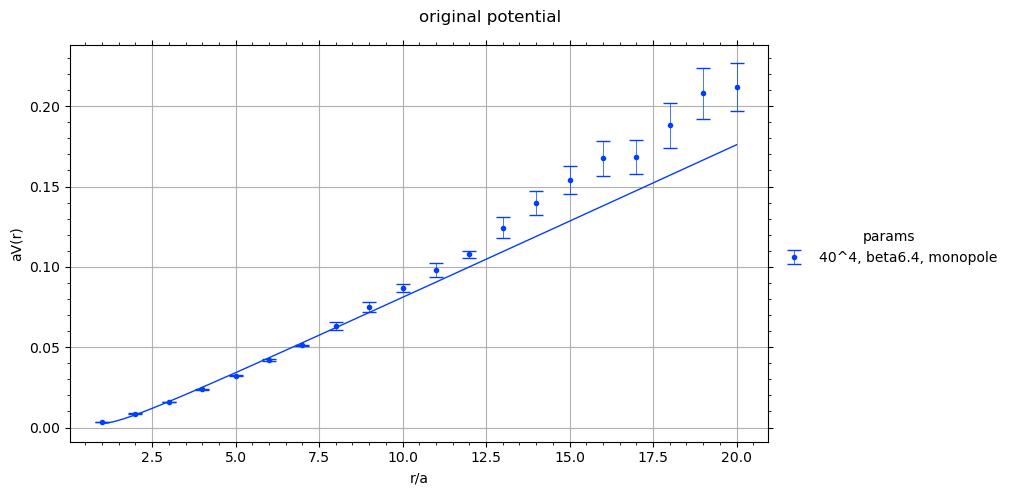

In [ ]:
plot_potential_gevp_single_monopole('40^4', 'beta6.4', 'HYP0_alpha=1_1_0.5_APE_alpha=0.5', 40, 40, 'steps_0/copies=20', 0)